In [1]:
%pip install matplotlib seaborn numpy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Step 1
#Import required libraries
# Core libraries for data analysis
import pandas as pd
import numpy as np
# pandas & numpy for data handling and matplotlib/seaborn to visually understand pattern

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for better readability
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
# step 2 moto
#1.How many rows (observations) we have

#2.How many columns (features) exist

#3.Whether train and test have similar structure

#load the ingested raw datasets
# Load the raw datasets saved during ingestion
train_df = pd.read_csv("../data/processed/cmi_sensor_data/train_raw.csv")
test_df = pd.read_csv("../data/processed/cmi_sensor_data/test_raw.csv")

# Check the shape of both datasets
train_df.shape, test_df.shape

((246846, 341), (107, 336))

In [4]:
#step 3 @ look at data Columns loaded correctly

#No obvious formatting issues

#Sensor values look numeric (not strings)
# View the first few rows of the training data
train_df.head()


,row_id,sequence_type,sequence_id,sequence_counter,subject,orientation,behavior,phase,gesture,acc_x,...,tof_5_v54,tof_5_v55,tof_5_v56,tof_5_v57,tof_5_v58,tof_5_v59,tof_5_v60,tof_5_v61,tof_5_v62,tof_5_v63
0,SEQ_000007_000000,Target,SEQ_000007,0,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.683594,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,SEQ_000007_000001,Target,SEQ_000007,1,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.949219,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,SEQ_000007_000002,Target,SEQ_000007,2,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,5.722656,...,-1.0,-1.0,112.0,119.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,SEQ_000007_000003,Target,SEQ_000007,3,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.601562,...,-1.0,-1.0,101.0,111.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,SEQ_000007_000004,Target,SEQ_000007,4,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,5.566406,...,-1.0,-1.0,101.0,109.0,125.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [5]:
#Understand column types and memory usage
#Which columns are numerical vs categorical

#Are there missing values

#Is any column incorrectly typed (e.g., numbers stored as objects)
# Get detailed information about the dataset
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 246846 entries, 0 to 246845
Columns: 341 entries, row_id to tof_5_v63
dtypes: float64(332), int64(1), str(8)
memory usage: 642.2 MB


In [6]:
# statistical summary of features
#Mean, min, max → sensor value ranges

#Standard deviation → how much sensors vary

#Helps identify outliers or unrealistic values
# Generate statistical summary for numerical columns
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
sequence_counter,246846.0,44.523590,49.366759,0.000000,17.000000,35.000000,55.000000,699.000000
acc_x,246846.0,1.642820,5.729166,-31.382812,-2.957031,2.914062,6.289062,38.097656
acc_y,246846.0,1.777569,5.016028,-21.109375,-2.125000,0.679688,6.789062,24.851562
acc_z,246846.0,-0.538758,6.141145,-42.855469,-5.535156,-1.671875,5.139648,23.812500
rot_w,244903.0,0.358374,0.226053,0.000000,0.177856,0.339050,0.501282,0.998596
...,...,...,...,...,...,...,...,...
tof_5_v59,234161.0,36.714171,64.363360,-1.000000,-1.000000,-1.000000,57.000000,249.000000
tof_5_v60,234161.0,34.451207,62.641344,-1.000000,-1.000000,-1.000000,50.000000,249.000000
tof_5_v61,234161.0,31.650843,60.236631,-1.000000,-1.000000,-1.000000,42.000000,249.000000
tof_5_v62,234161.0,28.957102,57.346530,-1.000000,-1.000000,-1.000000,34.000000,249.000000


In [7]:
#checking missing values per column
#Missing data directly affects:

#model performance

#Choice of preprocessing (imputation, dropping, etc.)

#Even zero missing values is an important finding and should be stated.
# Count missing values per column
missing_values = train_df.isnull().sum()

# Display only columns with missing data
missing_values[missing_values > 0]


rot_w         1943
rot_x         1943
rot_y         1943
rot_z         1943
thm_1         2869
             ...  
tof_5_v59    12685
tof_5_v60    12685
tof_5_v61    12685
tof_5_v62    12685
tof_5_v63    12685
Length: 329, dtype: int64

In [8]:
#target variable anaylsis(gesture)
#How many gesture classes we are predicting

#Whether the dataset is balanced or imbalance
#target variable analysis
# Check how many unique gesture classes exist
train_df["gesture"].nunique()


18

In [9]:
# Distribution of gesture classes
train_df["gesture"].value_counts()

gesture
Neck - scratch                                26307
Text on phone                                 23988
Forehead - scratch                            18643
Neck - pinch skin                             17933
Above ear - pull hair                         17797
Cheek - pinch skin                            17517
Eyelash - pull hair                           17425
Eyebrow - pull hair                           17408
Forehead - pull hairline                      17108
Wave hello                                    15376
Write name in air                             13222
Pull air toward your face                     13131
Feel around in tray and pull out an object     6645
Glasses on/off                                 6106
Scratch knee/leg skin                          5113
Drink from bottle/cup                          4996
Write name on leg                              4600
Pinch knee/leg skin                            3531
Name: count, dtype: int64

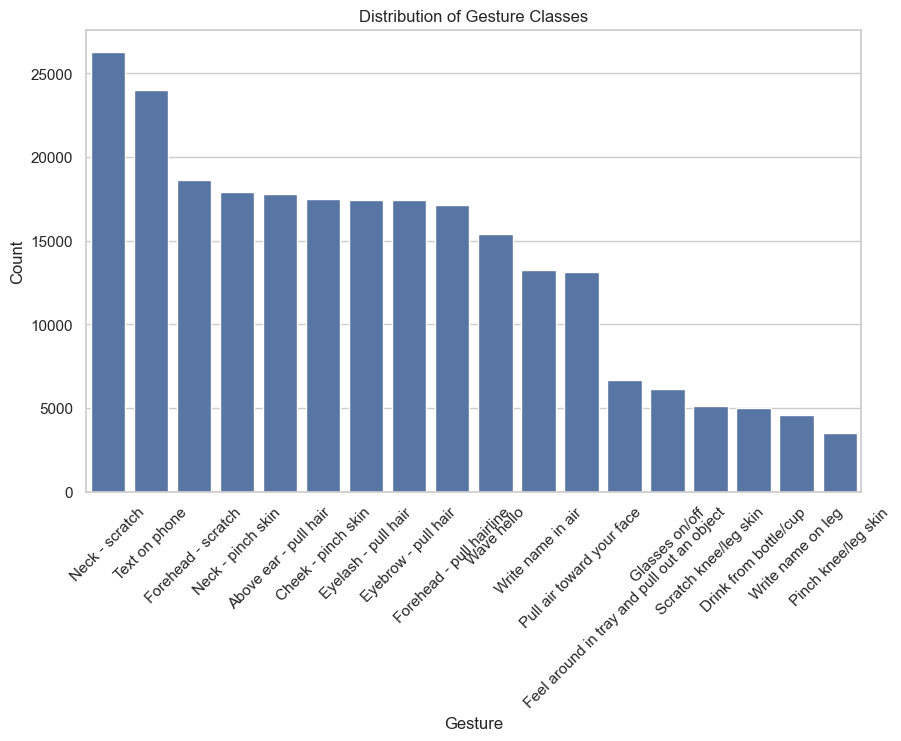

In [10]:
#visaulaize target distribution
#Imbalanced classes may require class weighting or resampling

#Visuals make imbalance obvious to reviewers and professors
# Plot distribution of gesture classes
sns.countplot(
    data=train_df,
    x="gesture",
    order=train_df["gesture"].value_counts().index
)

plt.title("Distribution of Gesture Classes")
plt.xlabel("Gesture")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#sensor feature distribution
#We don’t plot all sensor columns (too many),but sampling a few helps understand:Value ranges Skewness Presence of noise or spikes
# Select a few sensor columns (excluding target)
sensor_cols = train_df.drop(columns=["gesture"]).columns[:5]

# Plot distributions for selected sensor features
for col in sensor_cols:
    sns.histplot(train_df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
#Correlation analysis (numerical features)
#Highly correlated sensors may be redundant. Helps later during feature selection or dimensionality reduction
# Compute correlation matrix (excluding target)
#corr_matrix = train_df.drop(columns=["gesture"]).corr()
X = train_df.drop(columns=["gesture"], errors="ignore")
X_numeric = X.select_dtypes(include=["number"])
corr_matrix = X_numeric.corr()
# Plot heatmap for a subset (to keep it readable)
sns.heatmap(
    corr_matrix.iloc[:10, :10],
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap (Sample of Sensor Features)")
plt.show()

In [ ]:
#Compare train vs test structure
#This is a very real-world check to prevent bugs later during modeling.
# Ensure train and test have the same feature columns (except target)
set(train_df.columns) - set(test_df.columns)

In [ ]:
set(test_df.columns) - set(train_df.columns)

In [ ]:
### Key EDA Observations

- The dataset consists of multivariate sensor readings collected over time.
- The target variable `gesture` contains multiple distinct classes.
- No major structural differences were observed between train and test datasets.
- Sensor values vary significantly across features, indicating the need for scaling.
- Some gestures appear more frequently than others, suggesting mild class imbalance.
- No preprocessing or feature engineering has been applied at this stage.